# Ejercicio Iris — NumPy

**Copia de trabajo de `04 Multilayer perceptron.ipynb`.** El repositorio original no se modifica.
Este notebook está preparado, pero no tiene resultados ejecutados: ejecútalo en Google Colab.

Recorrido: A) original del curso; B) implementación general de cuatro capas y control corregido;
C) gráficas y métricas; D) descarga de evidencias. Todas las redes usan sigmoide, 0.03 y 500 épocas.
No cambies los datos, la tasa ni las épocas durante esta comparación.


In [1]:
import sys, json, platform
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
import numpy as np
ART = Path('evidencias_numpy')
ART.mkdir(exist_ok=True)
en_colab = 'google.colab' in sys.modules
if not en_colab:
    try:
        import google.colab
        en_colab = True
    except ImportError:
        pass
entorno = {'fecha_utc': datetime.now(timezone.utc).isoformat(),
            'python': platform.python_version(), 'numpy': np.__version__,
            'colab_detectado': en_colab}
print(entorno)
print('Toma una captura donde se vea la interfaz de Colab y el nombre del notebook.')
(ART / 'entorno.json').write_text(json.dumps(entorno, indent=2), encoding='utf-8')


{'fecha_utc': '2026-09-12T22:05:53.839093+00:00', 'python': '3.13.15', 'numpy': '2.1.3', 'colab_detectado': True}
Toma una captura donde se vea la interfaz de Colab y el nombre del notebook.


123

## A. Ejecutar la red original 4 → 3 → 3

Las siguientes celdas proceden del notebook original. Se conservan su topología, orden de datos,
regla de actualización y cálculo de error. Se añade una semilla y medición del tiempo.
Único ajuste de compatibilidad: `np.random.rand(1)` se cambia por `np.random.rand()` para producir
un escalar al asignar cada peso; la distribución de inicialización es la misma.

Ejecuta hasta la celda que muestra **Resultados NumPy original** y guarda una captura de la curva.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [3]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")

In [4]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


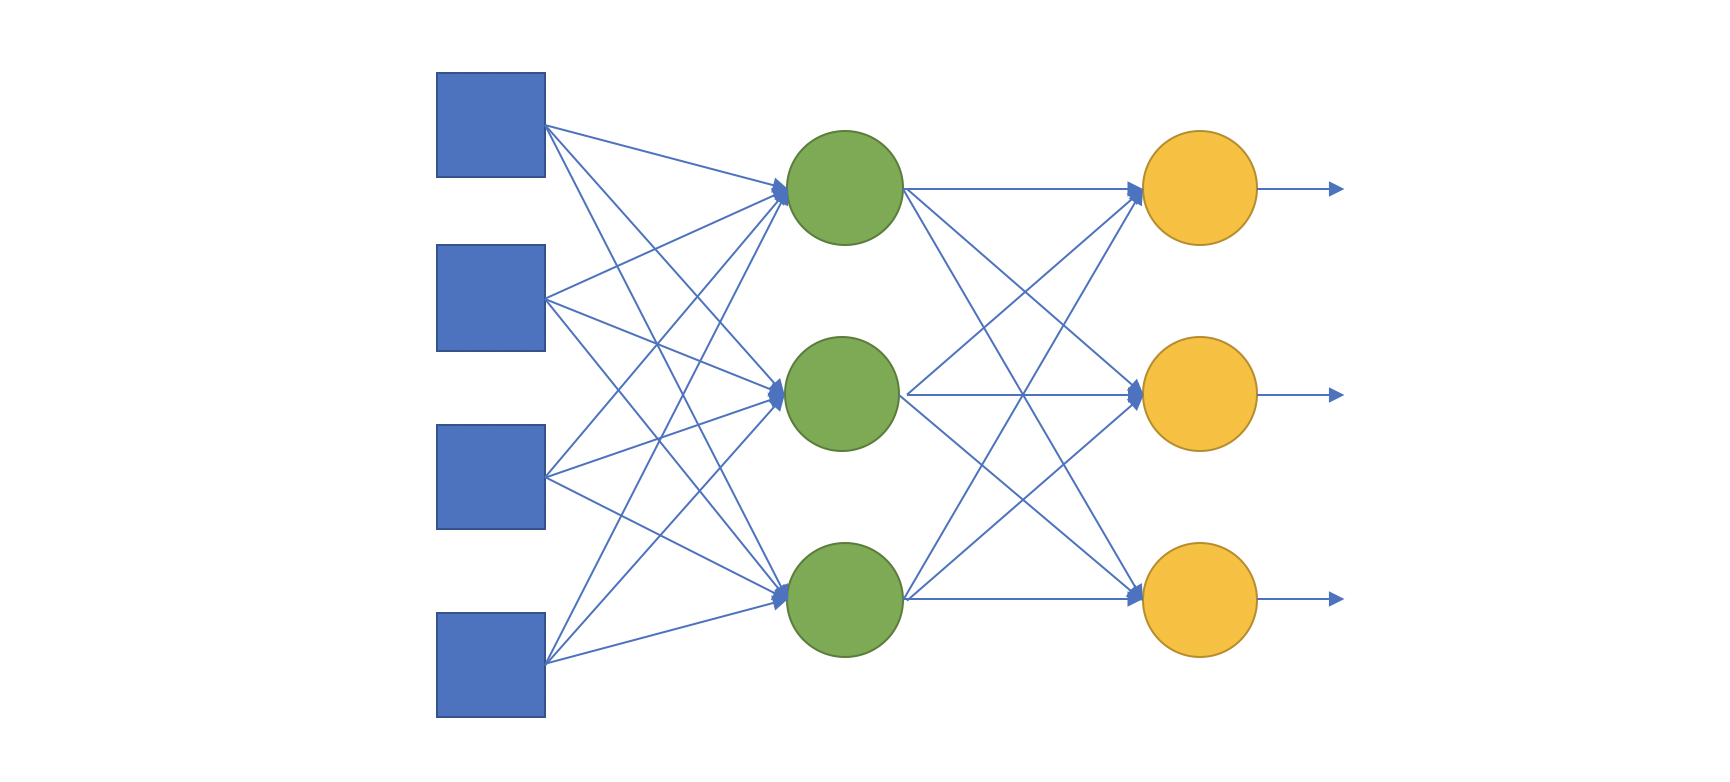

In [5]:
#Topology: 4 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

layer1 = list()
layer2 = list()

In [6]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = (np.random.rand() - 0.5)
  return w

def init_weights():
  layer1.clear()
  layer2.clear()
  for i in range(num_neurons_layer1):
    layer1.append( generate_weights(input_size_layer1+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer2):
    layer2.append( generate_weights(input_size_layer2+1)) # plus 1 -> plus bias

def net_input(input_vector, w):
  net_input_var = w[0]
  for i in range(len(input_vector)):
    net_input_var += w[i+1] * input_vector[i]
  return net_input_var

def sigmoid(z):
  activation = 1/(1+np.power(np.e, -z))
  return activation

def propagate(X, w):
  neuronInput = net_input(X, w) # Sigma
  neuronOutput = sigmoid(neuronInput) # sigma
  return neuronOutput

def calculate_error():
  total_err = 0
  for idx in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[idx], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    err = Y[idx] - output_layer2
    err = np.power(err,2)
    err = err.sum()
    total_err += err

  return total_err / ( len(X) )

In [7]:
print(generate_weights(5))

[ 0.46816432 -0.2150425   0.30913822 -0.05396738  0.46468756]


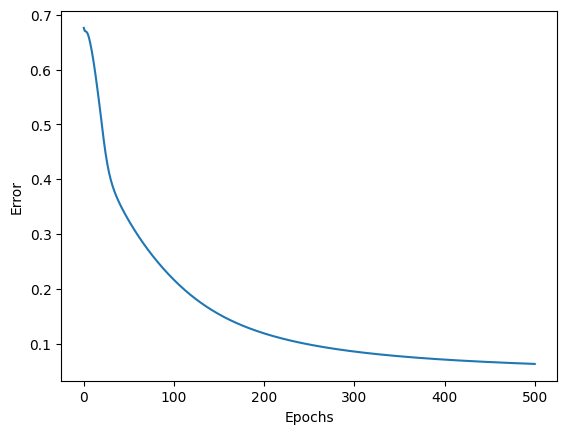

In [8]:
alpha = 0.03
epochs = 500

np.random.seed(42)
inicio_original = perf_counter()
init_weights()

E = list()
E.append( calculate_error() )
for e in range(epochs):
  for d in range(len(X)):
    # Etapa 1 - Propagación
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[d], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    # Etapa 2 - Retropropagación de los errores
    delta_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(delta_layer2)):
      delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * (Y[d][i] - output_layer2[i])

    for i in range(len(layer2)):
      layer2[i][0] += alpha * delta_layer2[i] * 1
      for j in range(len(layer2[i])-1):
        layer2[i][j+1] += alpha * delta_layer2[i] * output_layer1[j]

    delta_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(delta_layer1)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer2):
        weighted_delta_errors += layer2[i][j+1] * delta_layer2[j]
      delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

    for i in range(len(layer1)):
      layer1[i][0] += alpha * delta_layer1[i] * 1
      for j in range(len(layer1[i])-1):
        layer1[i][j+1] += alpha * delta_layer1[i] * X[d][j]

  E.append( calculate_error() )

segundos_original = perf_counter() - inicio_original
Error_vec = np.asarray(E)
plt.plot(Error_vec)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Resultados NumPy original
{
  "version": "Original del curso",
  "topologia": "4-3-3",
  "error_final_notebook": 0.0627910453770139,
  "mse_final": 0.020930348459004627,
  "accuracy_entrenamiento": 0.96,
  "segundos": 9.066687644000012
}


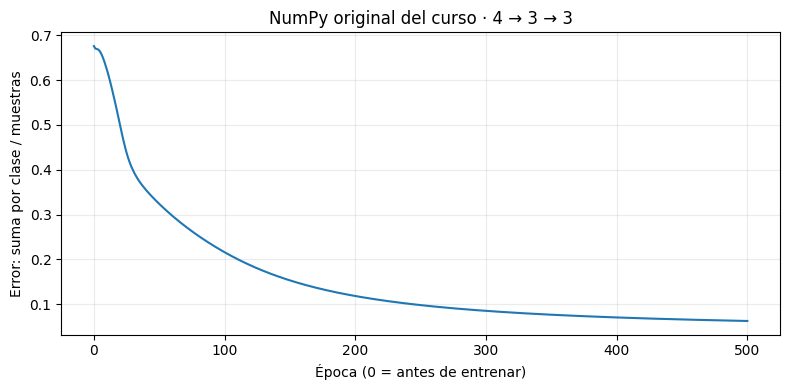

In [9]:
E_original = np.array(E, dtype=float).copy()
pred_original = []
for x in X:
    oculta = np.array([propagate(x, w) for w in layer1])
    pred_original.append([propagate(oculta, w) for w in layer2])
pred_original = np.asarray(pred_original)
resultado_original = {
    'version': 'Original del curso', 'topologia': '4-3-3',
    'error_final_notebook': float(E_original[-1]),
    'mse_final': float(np.mean((Y - pred_original) ** 2)),
    'accuracy_entrenamiento': float(np.mean(pred_original.argmax(axis=1) == target)),
    'segundos': segundos_original,
}
print('Resultados NumPy original')
print(json.dumps(resultado_original, indent=2, ensure_ascii=False))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(E_original)
ax.set(xlabel='Época (0 = antes de entrenar)', ylabel='Error: suma por clase / muestras',
       title='NumPy original del curso · 4 → 3 → 3')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ART / 'numpy_original.png', dpi=160)
plt.show()


## B. Agregar exactamente dos capas y corregir la propagación hacia atrás

En el código original se usa `layer2[i][j+1]` para regresar el error. Con la organización de sus
pesos debe usarse `layer2[j][i+1]`. Además, allí la capa de salida se actualiza **antes** de calcular
el delta oculto. La implementación de abajo calcula todos los deltas con los pesos del mismo
forward y después actualiza todos los pesos.

Para no atribuir a la profundidad los efectos de esta corrección, ejecutamos también un
**control adicional 4 → 3 → 3** con el mismo código corregido que la red profunda. La corrida
original anterior se conserva como evidencia del ejercicio.

Qué cambia: tamaños `[4,3,3,3,3]`, inicialización de cuatro matrices, forward por todas las capas,
cálculo de error a partir de la cuarta capa y backprop desde la cuarta hasta la primera.
Cada matriz tiene una fila por neurona y una columna extra para el sesgo.

Se conserva la escala de actualización del curso: delta de salida `(Y-H)*H*(1-H)`, que equivale
a descender sobre la mitad de la suma de cuadrados. La métrica `error` suma las tres salidas;
`mse` divide también entre tres. Esta diferencia de escala debe mencionarse frente a Keras.


In [10]:
def init_weights_general(tamanos, semilla=42):
    rng = np.random.RandomState(semilla)
    return [rng.uniform(-0.5, 0.5, (salidas, entradas + 1))
            for entradas, salidas in zip(tamanos[:-1], tamanos[1:])]

def forward_general(x, pesos):
    activaciones = [np.asarray(x, dtype=float)]
    for W in pesos:
        entrada_con_bias = np.concatenate(([1.0], activaciones[-1]))
        z = W @ entrada_con_bias
        activaciones.append(1.0 / (1.0 + np.exp(-z)))
    return activaciones

def predict_general(datos, pesos):
    return np.array([forward_general(x, pesos)[-1] for x in datos])

def calculate_error_general(datos, etiquetas, pesos):
    pred = predict_general(datos, pesos)
    return float(np.mean(np.sum((etiquetas - pred) ** 2, axis=1)))

def deltas_general(activaciones, y, pesos):
    deltas = [None] * len(pesos)
    h = activaciones[-1]
    deltas[-1] = (y - h) * h * (1 - h)
    for capa in range(len(pesos) - 2, -1, -1):
        h = activaciones[capa + 1]
        # Excluir sesgos y transponer: de la capa siguiente a la actual.
        error_atras = pesos[capa + 1][:, 1:].T @ deltas[capa + 1]
        deltas[capa] = h * (1 - h) * error_atras
    return deltas

def entrenar_general(tamanos, alpha=0.03, epochs=500, semilla=42):
    pesos = init_weights_general(tamanos, semilla)
    inicio = perf_counter()
    errores = [calculate_error_general(X, Y, pesos)]
    for epoca in range(epochs):
        # Mismo orden de las 150 muestras y SGD por ejemplo que en el curso.
        for x, y in zip(X, Y):
            activaciones = forward_general(x, pesos)
            deltas = deltas_general(activaciones, y, pesos)
            # Todos los deltas ya están calculados antes de actualizar pesos.
            for capa in range(len(pesos)):
                entrada = np.concatenate(([1.0], activaciones[capa]))
                pesos[capa] += alpha * np.outer(deltas[capa], entrada)
        errores.append(calculate_error_general(X, Y, pesos))
        if (epoca + 1) % 50 == 0:
            print(f'{tamanos} | época {epoca + 1}: error={errores[-1]:.6f}')
    segundos = perf_counter() - inicio
    pred = predict_general(X, pesos)
    resultado = {
        'topologia': '-'.join(map(str, tamanos)),
        'error_final_notebook': float(errores[-1]),
        'mse_final': float(np.mean((Y - pred) ** 2)),
        'accuracy_entrenamiento': float(np.mean(pred.argmax(axis=1) == target)),
        'segundos': segundos,
    }
    return pesos, np.asarray(errores), resultado


In [11]:
# Control adicional: red pequeña con el mismo backprop correcto de la profunda.
pesos_control, E_control, resultado_control = entrenar_general([4, 3, 3])
resultado_control['version'] = 'Control corregido'

# Red solicitada: tres capas ocultas de 3 neuronas y una salida de 3.
pesos_profunda, E_profunda, resultado_profunda = entrenar_general([4, 3, 3, 3, 3])
resultado_profunda['version'] = 'Profunda corregida'
layer1_profunda, layer2_profunda, layer3_profunda, layer4_profunda = pesos_profunda
print('Matrices de la red profunda (neuronas, entradas + sesgo):')
print([W.shape for W in pesos_profunda])
assert [W.shape for W in pesos_profunda] == [(3, 5), (3, 4), (3, 4), (3, 4)]


[4, 3, 3] | época 50: error=0.346480
[4, 3, 3] | época 100: error=0.248689
[4, 3, 3] | época 150: error=0.153458
[4, 3, 3] | época 200: error=0.111994
[4, 3, 3] | época 250: error=0.091080
[4, 3, 3] | época 300: error=0.078965
[4, 3, 3] | época 350: error=0.071258
[4, 3, 3] | época 400: error=0.066029
[4, 3, 3] | época 450: error=0.062321
[4, 3, 3] | época 500: error=0.059608
[4, 3, 3, 3, 3] | época 50: error=0.670597
[4, 3, 3, 3, 3] | época 100: error=0.670392
[4, 3, 3, 3, 3] | época 150: error=0.670225
[4, 3, 3, 3, 3] | época 200: error=0.670054
[4, 3, 3, 3, 3] | época 250: error=0.669827
[4, 3, 3, 3, 3] | época 300: error=0.669417
[4, 3, 3, 3, 3] | época 350: error=0.668285
[4, 3, 3, 3, 3] | época 400: error=0.662153
[4, 3, 3, 3, 3] | época 450: error=0.540626
[4, 3, 3, 3, 3] | época 500: error=0.406424
Matrices de la red profunda (neuronas, entradas + sesgo):
[(3, 5), (3, 4), (3, 4), (3, 4)]


## C. Guardar curvas y números

Guarda capturas de la original y la profunda. La figura de control es una evidencia adicional
que permite comentar el efecto de la profundidad con el mismo algoritmo de backprop.
La accuracy se calcula sobre los datos usados para entrenar; no es accuracy de prueba.
No se añadió un conjunto de prueba porque las corridas originales usan todo Iris.


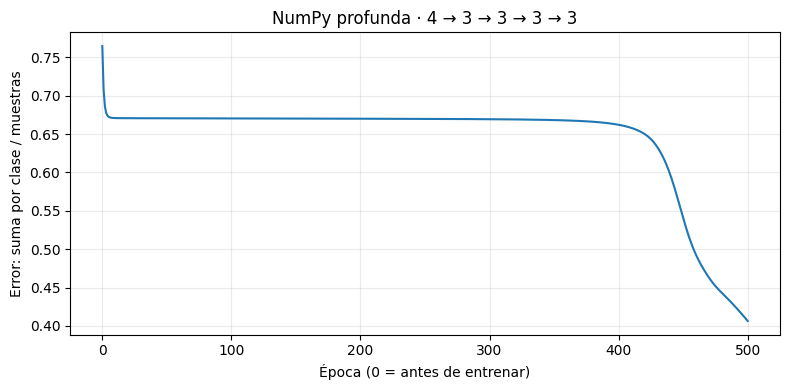

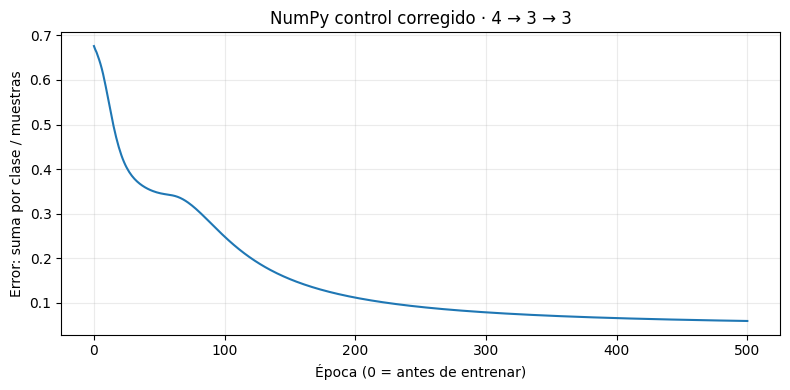

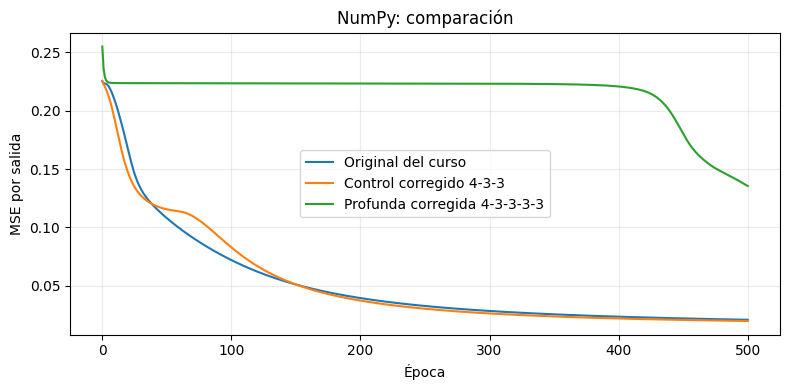

,version,topologia,error_final_notebook,mse_final,accuracy_entrenamiento,segundos
0,Original del curso,4-3-3,0.062791,0.020930,0.960000,9.066688
1,Control corregido,4-3-3,0.059608,0.019869,0.966667,5.874068
2,Profunda corregida,4-3-3-3-3,0.406424,0.135475,0.706667,9.992388


In [12]:
import pandas as pd
for titulo, curva, nombre in [
    ('NumPy profunda · 4 → 3 → 3 → 3 → 3', E_profunda, 'numpy_profunda.png'),
    ('NumPy control corregido · 4 → 3 → 3', E_control, 'numpy_control.png')]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(curva)
    ax.set(xlabel='Época (0 = antes de entrenar)', ylabel='Error: suma por clase / muestras', title=titulo)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(ART / nombre, dpi=160)
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(E_original / 3, label='Original del curso')
ax.plot(E_control / 3, label='Control corregido 4-3-3')
ax.plot(E_profunda / 3, label='Profunda corregida 4-3-3-3-3')
ax.set(xlabel='Época', ylabel='MSE por salida', title='NumPy: comparación')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(ART / 'numpy_comparacion.png', dpi=160)
plt.show()
tabla_numpy = pd.DataFrame([resultado_original, resultado_control, resultado_profunda])
display(tabla_numpy)
tabla_numpy.to_csv(ART / 'resultados_numpy.csv', index=False)
np.savez(ART / 'curvas_numpy.npz', original=E_original, control=E_control, profunda=E_profunda)


## D. Descargar las evidencias

La siguiente celda descarga un ZIP de figuras, métricas y registro del entorno.
Además toma una captura real de Colab y descarga este notebook desde Archivo → Descargar → .ipynb
**después de ejecutar**, para conservar sus salidas. El ZIP de imágenes no sustituye al notebook.


In [13]:
import shutil
archivo = shutil.make_archive('evidencias_numpy', 'zip', ART)
print('Evidencias generadas:', archivo)
try:
    from google.colab import files
    files.download(archivo)
except ImportError:
    print('Abre el archivo ZIP desde el entorno donde ejecutaste el notebook.')


Evidencias generadas: /content/evidencias_numpy.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>